In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix


In [3]:
zip_path = "/content/archive (2).zip"

extract_path = "heart_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Files extracted successfully!")

✅ Files extracted successfully!


In [4]:
print("Files in folder:", os.listdir(extract_path))

Files in folder: ['heart.csv']


In [5]:
df = pd.read_csv("/content/heart_data/heart.csv")

# **EXPLORATORY DATA ANALYSYS**

In [6]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [7]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [10]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [11]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [12]:
df.shape

(1025, 14)

In [13]:
df['target'].value_counts()

,count
target,
1,526
0,499


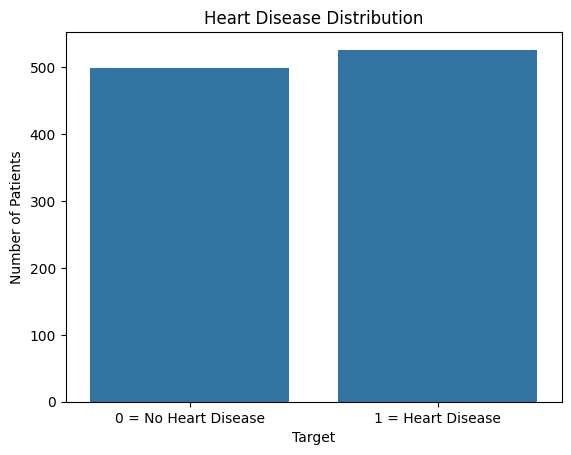

In [14]:
sns.countplot(x='target', data=df)

plt.title("Heart Disease Distribution")

plt.xticks(
    ticks=[0,1],
    labels=[
        '0 = No Heart Disease',
        '1 = Heart Disease'
    ]
)

plt.xlabel("Target")
plt.ylabel("Number of Patients")

plt.show()

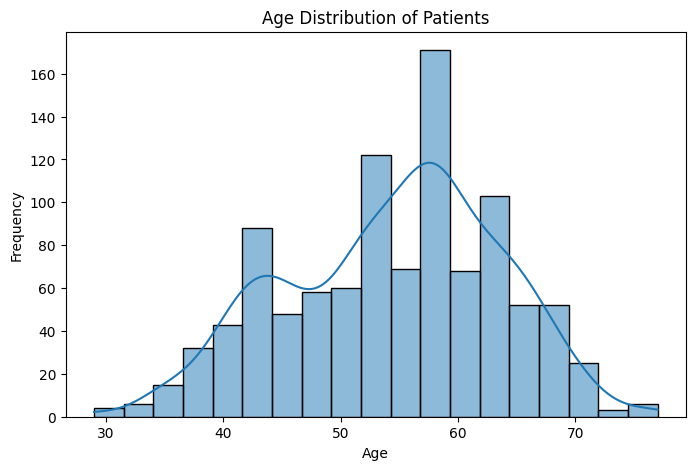

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], kde=True)

plt.title("Age Distribution of Patients")

plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

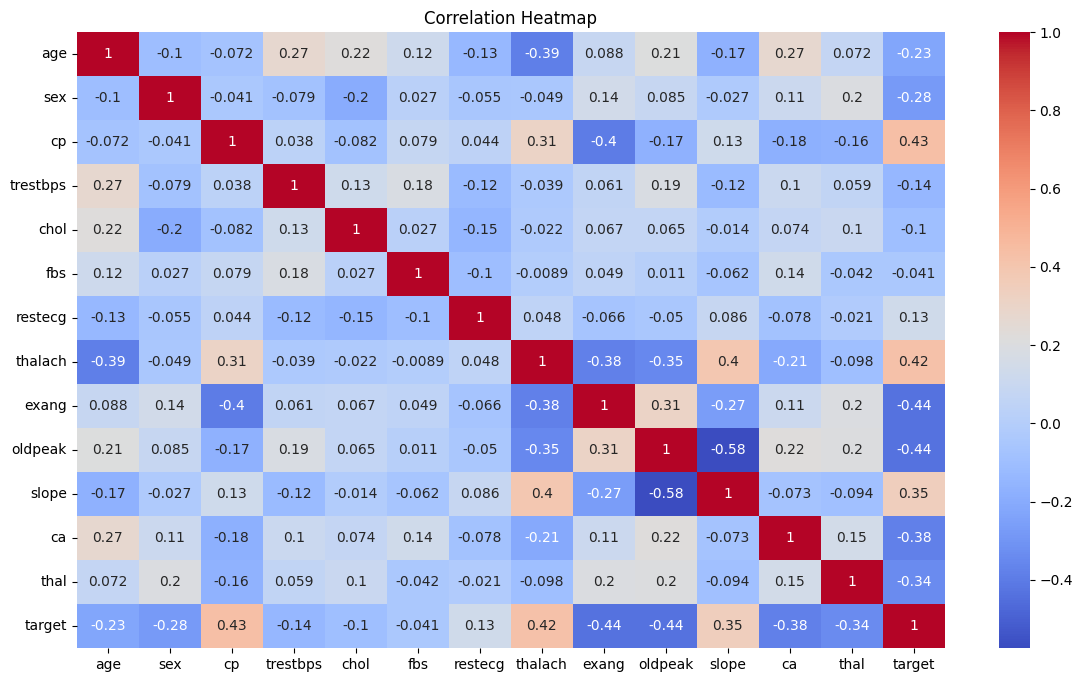

In [44]:
plt.figure(figsize=(14,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# **CHECKING OUTLIERS**

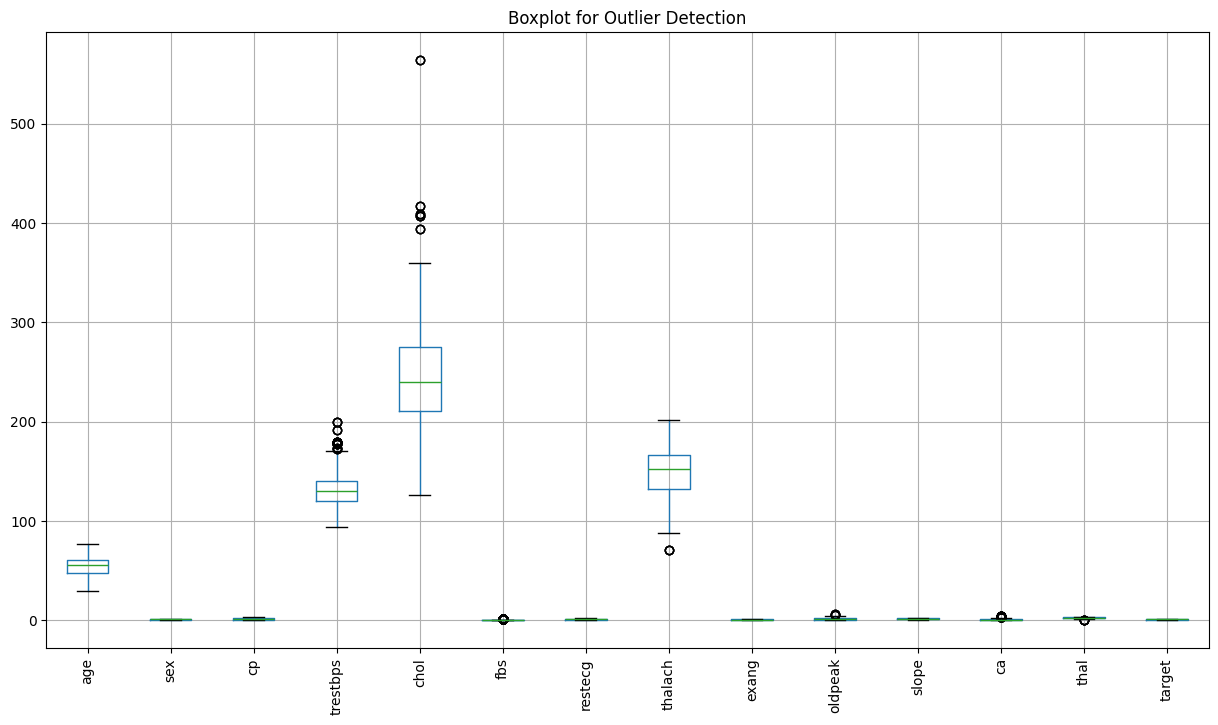

In [17]:
plt.figure(figsize=(15,8))

df.boxplot()

plt.xticks(rotation=90)

plt.title("Boxplot for Outlier Detection")

plt.show()

In [18]:
X = df.drop('target', axis=1)

y = df['target']

In [19]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2


In [20]:
y.head()

,target
0,0
1,0
2,0
3,0
4,0


# **TRAIN/TEST SPLIT**

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **FEATURE SCALER**

In [22]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# **LOGISTIC REGRESSION & MODEL EVALUTION**

In [23]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

LogisticRegression()

In [24]:
y_pred_lr = lr.predict(X_test)

In [25]:
accuracy_score(y_test, y_pred_lr)

0.7951219512195122

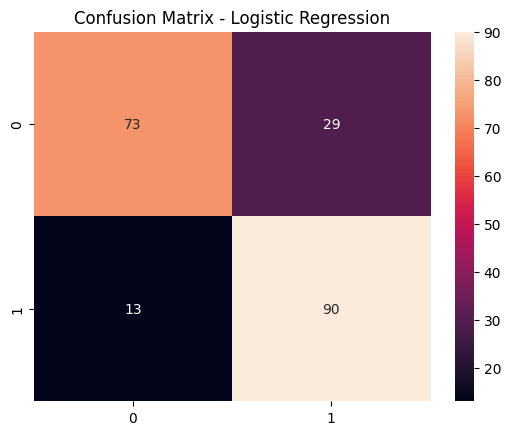

In [26]:
lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(lr, annot=True, fmt='d')

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

### Logistic Regression provided a moderate and stable performance. It correctly identified a good number of both disease and non-disease cases, but made some misclassifications. It is useful as a baseline model but not the most accurate for this dataset.

# **SUPPORT VECTOR MACHINE & MODEL EVALUTION**

In [27]:
svm = SVC()

svm.fit(X_train, y_train)

SVC()

In [28]:
y_pred_svm = svm.predict(X_test)

In [29]:
accuracy_score(y_test, y_pred_svm)

0.8878048780487805

In [30]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_svm

array([[85, 17],
       [ 6, 97]])

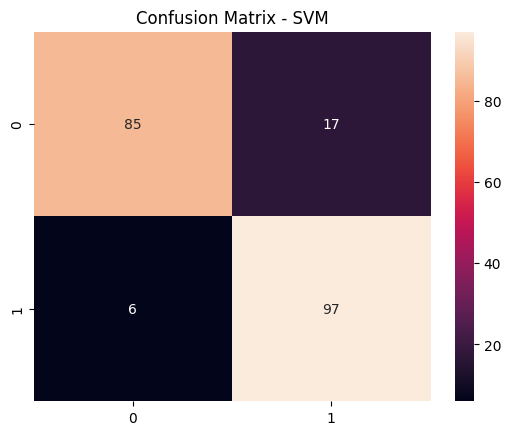

In [31]:

sns.heatmap(cm_svm, annot=True, fmt='d')

plt.title("Confusion Matrix - SVM")

plt.show()

### SVM delivered a strong performance with better classification accuracy compared to Logistic Regression. It reduced errors significantly and showed a good balance between predicting disease and non-disease cases. It performed well in separating both classes clearly.

# **RANDOM FOREST & MODEL EVALUTION**

In [32]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [33]:
y_pred_rf = rf.predict(X_test)

In [34]:
accuracy_score(y_test, y_pred_rf)

0.9853658536585366

In [35]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_rf

array([[102,   0],
       [  3, 100]])

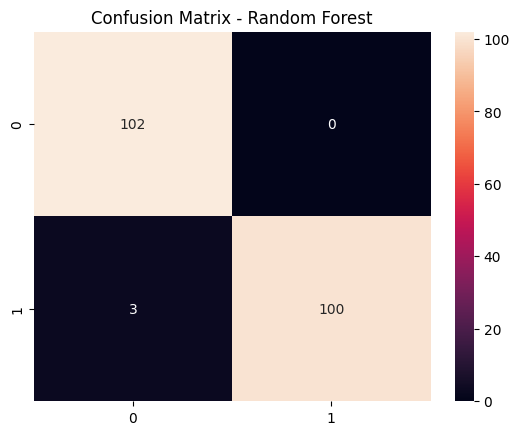

In [36]:
sns.heatmap(cm_rf, annot=True, fmt='d')

plt.title("Confusion Matrix - Random Forest")

plt.show()

 Random Forest delivered excellent performance on the heart disease dataset with very high prediction accuracy. The model correctly identified most healthy and diseased patients with very few misclassifications, demonstrating strong learning capability and reliable classification performance.

In [37]:
!pip install xgboost

# **XGBOOST & MODEL EVALUTION**

In [38]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:22:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [39]:
y_pred_xgb = xgb.predict(X_test)

In [40]:
accuracy_score(y_test, y_pred_xgb)

0.9853658536585366

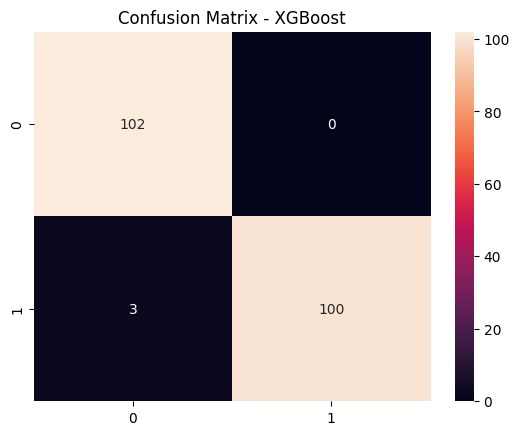

In [41]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm_xgb, annot=True, fmt='d')

plt.title("Confusion Matrix - XGBoost")



plt.show()

In [42]:
print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("XGB Accuracy:", accuracy_score(y_test, y_pred_xgb))

LR Accuracy: 0.7951219512195122
SVM Accuracy: 0.8878048780487805
RF Accuracy: 0.9853658536585366
XGB Accuracy: 0.9853658536585366


XGBoost achieved outstanding performance on the heart disease dataset with very high prediction accuracy and minimal classification errors. The model successfully identified most disease and non-disease cases while maintaining strong generalization capability, making it one of the most reliable models for this prediction task.

# **COMPARING MODELS**

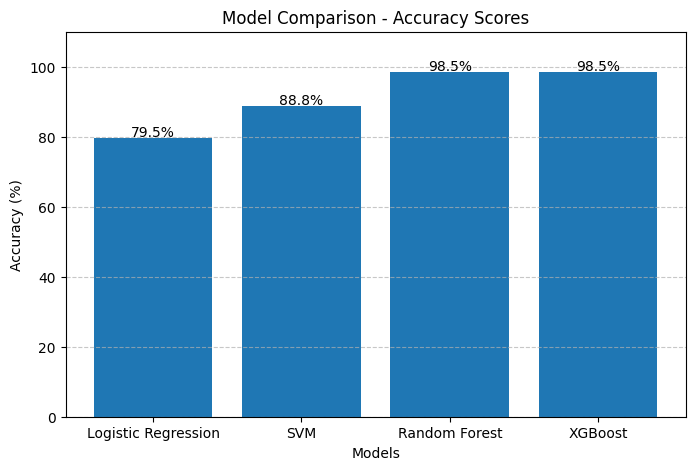

In [45]:
models = ['Logistic Regression', 'SVM', 'Random Forest', 'XGBoost']

accuracies = [79.5, 88.8, 98.5, 98.5]


plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison - Accuracy Scores")

# Accuracy values show on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5,
             f'{yval}%', ha='center')

plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [46]:
import pickle

pickle.dump(xgb, open('heart_model.pkl', 'wb'))

In [47]:
pickle.dump(scaler, open('scaler.pkl', 'wb'))